# 06 — Historical Regime Analysis & Data Quality

This notebook has two sections:

**Part A — Data Quality**  
Per-ticker diagnostics: missing values, consecutive gaps, zero-return days,
5sigma outliers, skewness/kurtosis, annualised volatility, pairwise coverage overlap.

**Part B — Historical Regime Analysis**  
How do crypto vs traditional-asset rolling correlations behave across major
market regimes? Regimes covered:
- Crypto Bull 2017 / Bear 2018
- Calm 2019
- COVID Crash & Recovery (2020)
- Crypto Bull 2021
- Rate Hike Cycle / Terra-Luna Collapse / FTX Collapse (2022)
- Crypto Recovery 2023
- BTC ETF / Halving 2024

In [1]:
import sys, os
ROOT = r"D:\clode9"
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from thesis_app.pipeline import load_config, build_paths, fetch_prices, compute_returns
from thesis_app.notebook_helpers import apply_thesis_plot_style
from thesis_app.data_quality import run_data_quality_report, check_coverage_overlap
from thesis_app.regime_analysis import (
    REGIMES, run_regime_analysis,
    plot_rolling_corr_with_regimes, plot_regime_corr_boxplot,
    plot_all_pairs_regime_heatmap, compute_regime_stats,
)

apply_thesis_plot_style()
%matplotlib inline

cfg   = load_config(os.path.join(ROOT, "config.yaml"))
paths = build_paths(cfg["base_dir"])

tickers = cfg["assets"]["crypto"] + cfg["assets"]["traditional"]
prices  = fetch_prices(paths, tickers, cfg["start_date"], cfg.get("end_date"))
returns = compute_returns(paths, prices)

base    = cfg["base_asset"]
others  = [t for t in tickers if t != base]
windows = cfg["rolling_windows"]

print(f"Prices: {prices.shape}  {prices.index[0].date()} -> {prices.index[-1].date()}")
print("Tickers:", list(prices.columns))

Loaded prices from cache: D:/clode9\data\raw\prices.csv
Prices: (2976, 7)  2017-11-09 -> 2026-02-27
Tickers: ['BTC-USD', 'ETH-USD', 'GLD', 'SLV', 'UUP', '^GSPC', '^IXIC']


---
## Part A — Data Quality

In [2]:
quality_dir = os.path.join(paths.tables, "data_quality")
dq = run_data_quality_report(prices, output_dir=quality_dir, sigma_threshold=5.0)
display(dq["stats"])

[data_quality] Artefacts saved to D:/clode9\outputs\tables\data_quality


,first_date,last_date,n_obs,n_calendar_days,pct_missing,n_missing_price,n_gaps_1d,n_gaps_2d,n_gaps_gt2d,n_zero_returns,n_outliers_5s,skewness,excess_kurtosis,annualised_vol_pct
ticker,,,,,,,,,,,,,,
BTC-USD,2017-11-09,2026-02-27,2976,3033,0.0,0,2918,57,0,0,4,-0.730,13.351,56.34
ETH-USD,2017-11-09,2026-02-27,2976,3033,0.0,0,2918,57,0,0,5,-0.741,10.754,72.99
GLD,2017-11-09,2026-02-27,2976,3033,0.0,0,2918,57,0,898,8,-0.877,14.914,13.49
SLV,2017-11-09,2026-02-27,2976,3033,0.0,0,2918,57,0,932,5,-2.914,55.761,27.73
UUP,2017-11-09,2026-02-27,2976,3033,0.0,0,2918,57,0,979,6,-0.023,8.697,5.85
^GSPC,2017-11-09,2026-02-27,2976,3033,0.0,0,2918,57,0,892,13,-0.747,22.783,16.23
^IXIC,2017-11-09,2026-02-27,2976,3033,0.0,0,2918,57,0,893,8,-0.468,12.804,19.68


In [3]:
print("Pairwise observation overlap:")
display(dq["overlap"])

Pairwise observation overlap:


,BTC-USD,ETH-USD,GLD,SLV,UUP,^GSPC,^IXIC
BTC-USD,2976,2976,2976,2976,2976,2976,2976
ETH-USD,2976,2976,2976,2976,2976,2976,2976
GLD,2976,2976,2976,2976,2976,2976,2976
SLV,2976,2976,2976,2976,2976,2976,2976
UUP,2976,2976,2976,2976,2976,2976,2976
^GSPC,2976,2976,2976,2976,2976,2976,2976
^IXIC,2976,2976,2976,2976,2976,2976,2976


In [4]:
from thesis_app.data_quality import plot_missing_heatmap, plot_return_outliers, plot_price_coverage
plot_missing_heatmap(prices)
plt.show()

In [5]:
plot_price_coverage(prices)
plt.show()

In [6]:
plot_return_outliers(returns, sigma_threshold=5.0)
plt.show()

ret_btc = returns[base].dropna()
z_btc   = (ret_btc - ret_btc.mean()) / ret_btc.std()
btc_outliers = ret_btc[z_btc.abs() > 5]
print(f"BTC-USD |z|>5sigma: {len(btc_outliers)} observations")
print(btc_outliers.sort_values().to_string())

BTC-USD |z|>5sigma: 4 observations
Date
2020-03-12   -0.464730
2018-01-16   -0.181117
2017-12-06    0.181724
2017-12-07    0.225119


In [7]:
print(dq["latex"])

\begin{table}[H]
\centering
\small
\caption{Data quality summary per ticker}
\label{tab:data_quality}
\begin{tabular}{lrrrrrrrrr}
\toprule
Ticker & First obs. & Last obs. & N & \% miss. & Gaps $>$2d & Zero ret. & Skew & Ex.Kurt & Ann.Vol (\%) \\
\midrule
BTC-USD & 2017-11-09 & 2026-02-27 & 2976 & 0.00 & 0 & 0 & -0.73 & 13.35 & 56.34 \\
ETH-USD & 2017-11-09 & 2026-02-27 & 2976 & 0.00 & 0 & 0 & -0.74 & 10.75 & 72.99 \\
GLD & 2017-11-09 & 2026-02-27 & 2976 & 0.00 & 0 & 898 & -0.88 & 14.91 & 13.49 \\
SLV & 2017-11-09 & 2026-02-27 & 2976 & 0.00 & 0 & 932 & -2.91 & 55.76 & 27.73 \\
UUP & 2017-11-09 & 2026-02-27 & 2976 & 0.00 & 0 & 979 & -0.02 & 8.70 & 5.85 \\
^GSPC & 2017-11-09 & 2026-02-27 & 2976 & 0.00 & 0 & 892 & -0.75 & 22.78 & 16.23 \\
^IXIC & 2017-11-09 & 2026-02-27 & 2976 & 0.00 & 0 & 893 & -0.47 & 12.80 & 19.68 \\
\bottomrule
\end{tabular}
\end{table}


---
## Part B — Historical Regime Analysis

In [8]:
regime_df = pd.DataFrame(
    [(k.replace(chr(10), " "), v[0], v[1], v[3]) for k, v in REGIMES.items()],
    columns=["Regime", "Start", "End", "Description"]
)
display(regime_df)

,Regime,Start,End,Description
0,Crypto Bull 2017,2017-01-01,2017-12-17,Initial crypto bull run
1,Crypto Bear 2018,2018-01-01,2018-12-31,Post-ATH bear market
2,Calm 2019,2019-01-01,2019-12-31,Low-volatility recovery
3,COVID Crash,2020-02-20,2020-03-23,Global pandemic shock
4,COVID Recovery,2020-03-24,2020-12-31,Central bank liquidity surge
5,Crypto Bull 2021,2021-01-01,2021-11-10,"All-time highs, institutional entry"
6,Rate Hike Cycle,2022-01-01,2022-06-15,"Fed tightening, risk-off"
7,Terra/Luna Collapse,2022-05-01,2022-06-30,Algorithmic stablecoin failure
8,FTX Collapse,2022-11-01,2022-11-30,Centralised exchange failure
9,Crypto Recovery 2023,2023-01-01,2023-12-31,Gradual market normalisation


In [9]:
regime_dir = os.path.join(paths.tables, "regimes")
regime_results = run_regime_analysis(
    prices, base=base, others=others,
    windows=windows, output_dir=regime_dir
)
print(f"Done. Artefacts in: {regime_dir}")

[regime_analysis] Saved artefacts for BTC-USD/ETH-USD w=14
[regime_analysis] Saved artefacts for BTC-USD/ETH-USD w=30
[regime_analysis] Saved artefacts for BTC-USD/ETH-USD w=60
[regime_analysis] Saved artefacts for BTC-USD/ETH-USD w=90
[regime_analysis] Saved artefacts for BTC-USD/^GSPC w=14
[regime_analysis] Saved artefacts for BTC-USD/^GSPC w=30
[regime_analysis] Saved artefacts for BTC-USD/^GSPC w=60
[regime_analysis] Saved artefacts for BTC-USD/^GSPC w=90
[regime_analysis] Saved artefacts for BTC-USD/^IXIC w=14
[regime_analysis] Saved artefacts for BTC-USD/^IXIC w=30
[regime_analysis] Saved artefacts for BTC-USD/^IXIC w=60
[regime_analysis] Saved artefacts for BTC-USD/^IXIC w=90
[regime_analysis] Saved artefacts for BTC-USD/GLD w=14
[regime_analysis] Saved artefacts for BTC-USD/GLD w=30
[regime_analysis] Saved artefacts for BTC-USD/GLD w=60
[regime_analysis] Saved artefacts for BTC-USD/GLD w=90
[regime_analysis] Saved artefacts for BTC-USD/SLV w=14
[regime_analysis] Saved artefacts

In [10]:
# Annotated rolling-correlation plots: BTC vs each asset (w=30)
w = 30
for other in others:
    if other not in returns.columns:
        continue
    corr = returns[base].rolling(w).corr(returns[other]).dropna()
    fig = plot_rolling_corr_with_regimes(corr, pair_label=f"{base} / {other}", window=w)
    plt.show()

In [11]:
for other in ["^GSPC", "GLD"]:
    if other not in returns.columns:
        continue
    fig = plot_regime_corr_boxplot(returns, base, other, window=30)
    plt.show()

In [12]:
all_pairs = [(base, o) for o in others if o in returns.columns]
fig = plot_all_pairs_regime_heatmap(returns, all_pairs)
plt.show()

In [13]:
w = 30
key = ("^GSPC", w)
if key in regime_results:
    display(regime_results[key]["stats"])
    print(regime_results[key]["latex"])

,regime,description,start,end,n_obs,mean_corr,median_corr,std_corr,min_corr,max_corr,ann_vol_pct
0,Crypto Bull 2017,Initial crypto bull run,2017-01-01,2017-12-17,9,0.016,0.001,0.044,-0.027,0.110,103.9
1,Crypto Bear 2018,Post-ATH bear market,2018-01-01,2018-12-31,359,0.106,0.102,0.240,-0.390,0.569,68.1
2,Calm 2019,Low-volatility recovery,2019-01-01,2019-12-31,360,-0.025,-0.005,0.150,-0.376,0.459,56.7
3,COVID Crash,Global pandemic shock,2020-02-20,2020-03-23,33,0.321,0.301,0.193,0.019,0.591,152.7
4,COVID Recovery,Central bank liquidity surge,2020-03-24,2020-12-31,278,0.317,0.356,0.220,-0.211,0.794,47.0
5,Crypto Bull 2021,"All-time highs, institutional entry",2021-01-01,2021-11-10,307,0.268,0.307,0.190,-0.232,0.583,69.0
6,Rate Hike Cycle,"Fed tightening, risk-off",2022-01-01,2022-06-15,162,0.521,0.510,0.154,0.225,0.792,58.9
7,Terra/Luna Collapse,Algorithmic stablecoin failure,2022-05-01,2022-06-30,59,0.584,0.565,0.155,0.225,0.792,72.0
8,FTX Collapse,Centralised exchange failure,2022-11-01,2022-11-30,30,0.539,0.546,0.077,0.238,0.620,69.2
9,Crypto Recovery 2023,Gradual market normalisation,2023-01-01,2023-12-31,357,0.188,0.185,0.205,-0.231,0.579,36.6


\begin{table}[H]
\centering
\small
\caption{Rolling 30-day Pearson correlation by historical regime: BTC-USD / ^GSPC}
\label{tab:regime_corr_BTCUSDGSPC}
\begin{tabular}{lrrrrrrrr}
\toprule
ho$ & Ann.Vol (\%) \\& $N$ & $\bar{\rho}$ & $\sigma_\rho$ & Min $
\midrule
Crypto Bull 2017 & 2017-01-01 & 2017-12-17 & 9 & 0.016 & 0.044 & -0.027 & 0.110 & 103.9 \\
Crypto Bear 2018 & 2018-01-01 & 2018-12-31 & 359 & 0.106 & 0.240 & -0.390 & 0.569 & 68.1 \\
Calm 2019 & 2019-01-01 & 2019-12-31 & 360 & -0.025 & 0.150 & -0.376 & 0.459 & 56.7 \\
COVID Crash & 2020-02-20 & 2020-03-23 & 33 & 0.321 & 0.193 & 0.019 & 0.591 & 152.7 \\
COVID Recovery & 2020-03-24 & 2020-12-31 & 278 & 0.317 & 0.220 & -0.211 & 0.794 & 47.0 \\
Crypto Bull 2021 & 2021-01-01 & 2021-11-10 & 307 & 0.268 & 0.190 & -0.232 & 0.583 & 69.0 \\
Rate Hike Cycle & 2022-01-01 & 2022-06-15 & 162 & 0.521 & 0.154 & 0.225 & 0.792 & 58.9 \\
Terra/Luna Collapse & 2022-05-01 & 2022-06-30 & 59 & 0.584 & 0.155 & 0.225 & 0.792 & 72.0 \\
FTX Collapse & 2

In [14]:
w = 30
key = ("GLD", w)
if key in regime_results:
    display(regime_results[key]["stats"])

,regime,description,start,end,n_obs,mean_corr,median_corr,std_corr,min_corr,max_corr,ann_vol_pct
0,Crypto Bull 2017,Initial crypto bull run,2017-01-01,2017-12-17,9,-0.340,-0.352,0.060,-0.400,-0.211,103.9
1,Crypto Bear 2018,Post-ATH bear market,2018-01-01,2018-12-31,359,-0.071,-0.041,0.230,-0.685,0.498,68.1
2,Calm 2019,Low-volatility recovery,2019-01-01,2019-12-31,360,0.169,0.175,0.172,-0.213,0.506,56.7
3,COVID Crash,Global pandemic shock,2020-02-20,2020-03-23,33,0.168,0.151,0.185,-0.157,0.550,152.7
4,COVID Recovery,Central bank liquidity surge,2020-03-24,2020-12-31,278,0.357,0.386,0.201,-0.259,0.630,47.0
5,Crypto Bull 2021,"All-time highs, institutional entry",2021-01-01,2021-11-10,307,0.003,0.032,0.206,-0.475,0.604,69.0
6,Rate Hike Cycle,"Fed tightening, risk-off",2022-01-01,2022-06-15,162,-0.046,-0.056,0.187,-0.404,0.350,58.9
7,Terra/Luna Collapse,Algorithmic stablecoin failure,2022-05-01,2022-06-30,59,0.062,0.062,0.145,-0.248,0.350,72.0
8,FTX Collapse,Centralised exchange failure,2022-11-01,2022-11-30,30,0.333,0.287,0.140,0.001,0.598,69.2
9,Crypto Recovery 2023,Gradual market normalisation,2023-01-01,2023-12-31,357,0.079,0.105,0.243,-0.578,0.492,36.6


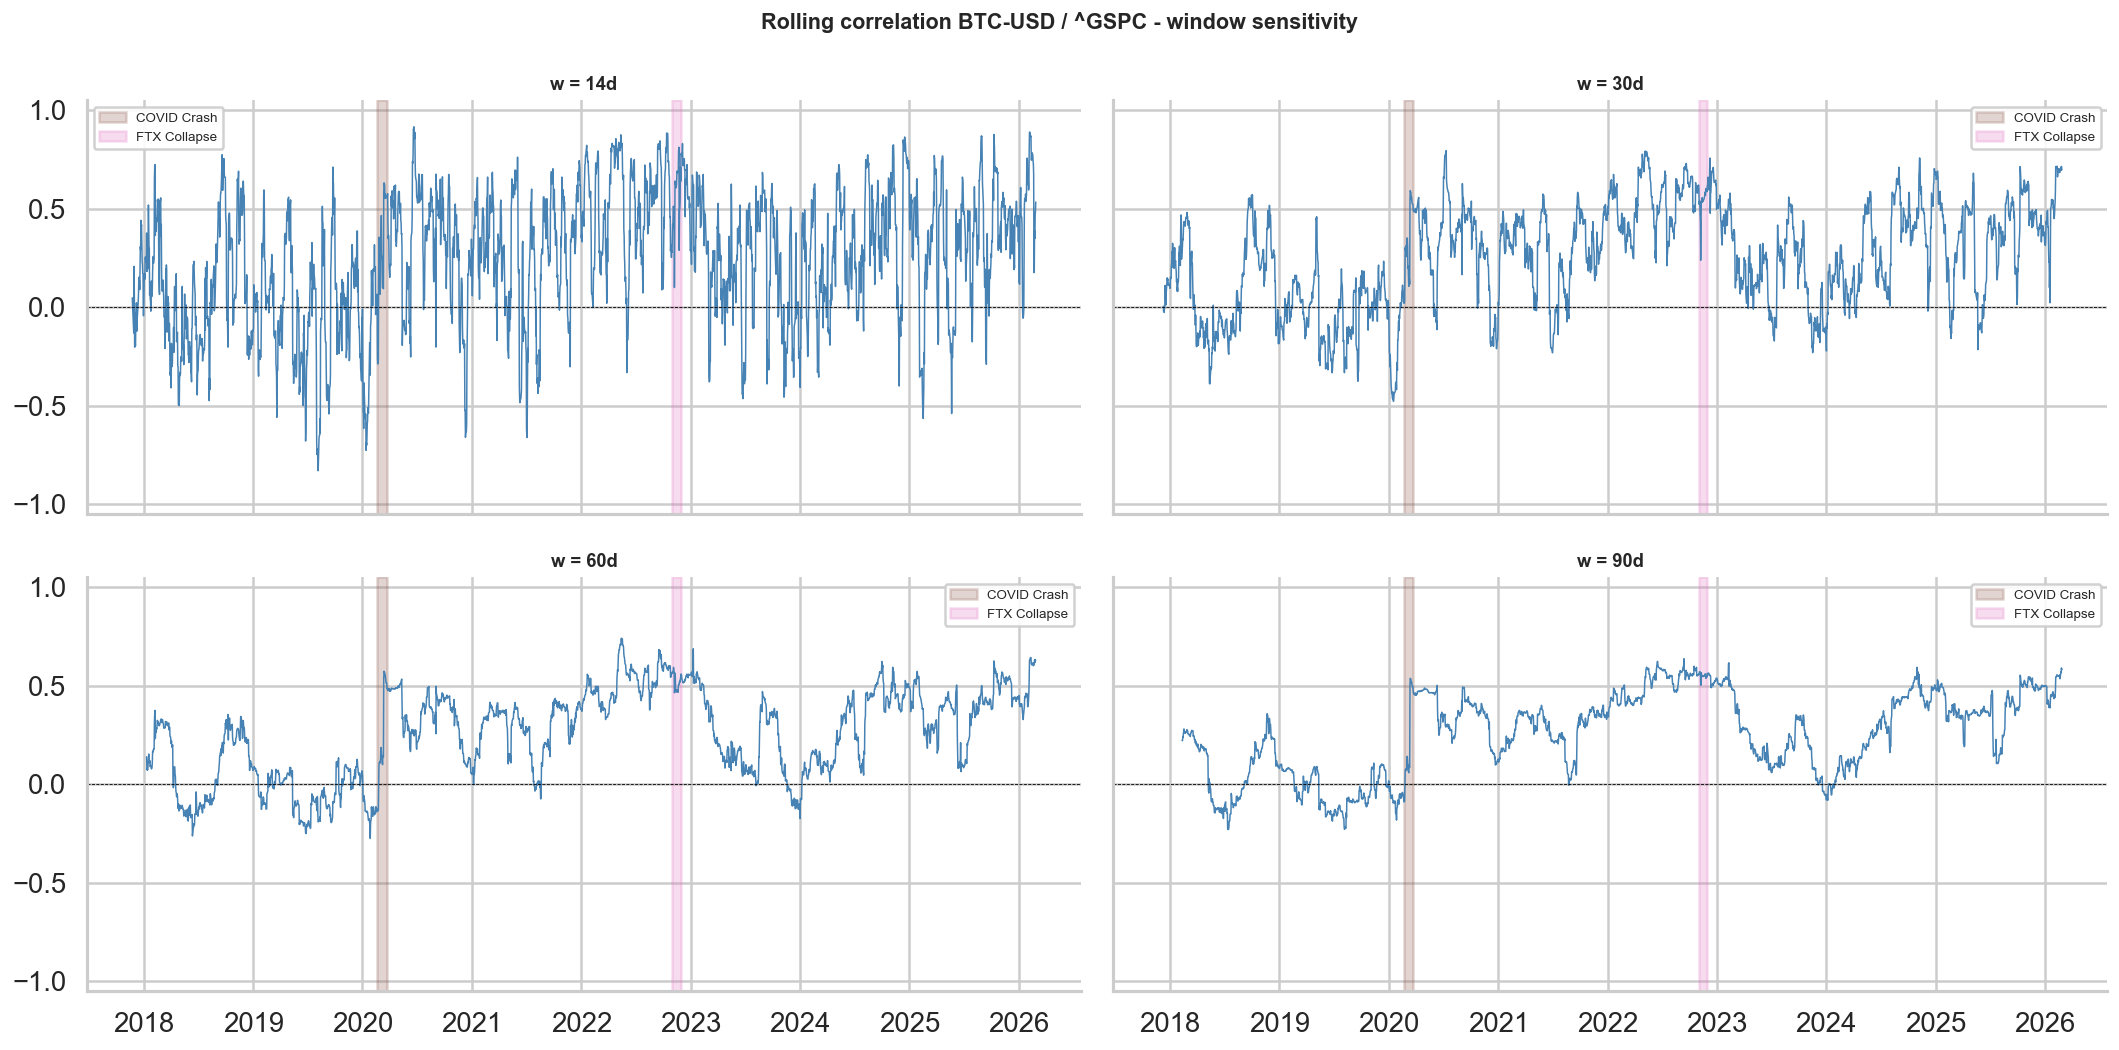

In [15]:
# Window sensitivity
other_check = "^GSPC"
fig, axes = plt.subplots(2, 2, figsize=(18, 9), sharex=True, sharey=True)
for idx, w in enumerate(windows):
    ax = axes.flatten()[idx]
    corr = returns[base].rolling(w).corr(returns[other_check]).dropna()
    ax.plot(corr.index, corr.values, color="steelblue", lw=0.9)
    ax.axhline(0, color="black", lw=0.5, ls="--")
    ax.axvspan(pd.Timestamp("2020-02-20"), pd.Timestamp("2020-03-23"), color="#8c564b", alpha=0.25, label="COVID Crash")
    ax.axvspan(pd.Timestamp("2022-11-01"), pd.Timestamp("2022-11-30"), color="#e377c2", alpha=0.25, label="FTX Collapse")
    ax.set_title(f"w = {w}d", fontsize=11, fontweight="bold")
    ax.set_ylim(-1.05, 1.05)
    ax.legend(fontsize=8)
fig.suptitle(f"Rolling correlation {base} / {other_check} - window sensitivity", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(paths.figures, "regime_window_sensitivity_BTCUSD_GSPC.png"), dpi=140)
plt.show()

In [16]:
print("=== KEY FINDINGS ===")
for other in ["^GSPC", "GLD", "ETH-USD"]:
    if other not in returns.columns:
        continue
    corr30 = returns[base].rolling(30).corr(returns[other]).dropna()
    stats = compute_regime_stats(corr30, returns[base])
    if stats.empty:
        continue
    max_abs = stats.loc[stats["mean_corr"].abs().idxmax()]
    max_pos = stats.loc[stats["mean_corr"].idxmax()]
    min_val = stats.loc[stats["mean_corr"].idxmin()]
    print(f"{base} vs {other} (30d):")
    print(f"  Max |rho| regime: {max_abs["regime"]}  rho={max_abs["mean_corr"]:.3f}")
    print(f"  Most positive:   {max_pos["regime"]}  rho={max_pos["mean_corr"]:.3f}")
    print(f"  Most negative:   {min_val["regime"]}  rho={min_val["mean_corr"]:.3f}")
    print(f"  Full-sample mean: {corr30.mean():.3f}")

=== KEY FINDINGS ===
BTC-USD vs ^GSPC (30d):
  Max |rho| regime: Terra/Luna Collapse  rho=0.584
  Most positive:   Terra/Luna Collapse  rho=0.584
  Most negative:   Calm 2019  rho=-0.025
  Full-sample mean: 0.253
BTC-USD vs GLD (30d):
  Max |rho| regime: COVID Recovery  rho=0.357
  Most positive:   COVID Recovery  rho=0.357
  Most negative:   Crypto Bull 2017  rho=-0.340
  Full-sample mean: 0.104
BTC-USD vs ETH-USD (30d):
  Max |rho| regime: FTX Collapse  rho=0.960
  Most positive:   FTX Collapse  rho=0.960
  Most negative:   Crypto Bull 2017  rho=-0.121
  Full-sample mean: 0.825


In [17]:
print("Regime analysis complete.")
print(f"  Figures -> {paths.figures}")
print(f"  Tables  -> {regime_dir}")

Regime analysis complete.
  Figures -> D:/clode9\outputs\figures
  Tables  -> D:/clode9\outputs\tables\regimes
